# Conditional Monte Carlo for a density

Author: Fred J. Hickernell

Conditioning gives an analytic conditional CDF and density. It reduces variance for CDF estimation and gives a direct density estimator for IID Monte Carlo and randomized low discrepancy points.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/sampling/ConditionalMonteCarlo.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vU}{\boldsymbol{U}}$


In [2]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## A weighted sum of uniforms

Write the simulator on uniform inputs as $Y=h(\vU)=\sum_{j=1}^d \gamma_j U_j$ for independent $U_j\sim\operatorname{Unif}(0,1)$ and positive weights. Given $U_2,\ldots,U_d$, the conditional density at $y$ is
$$
g_y(U_2,\ldots,U_d)=\frac1{\gamma_1}\mathbf1\left\{0\le y-\sum_{j=2}^d \gamma_jU_j\le \gamma_1\right\}.
$$
Thus $\varrho_Y(y)=\mathbb E[g_y(U_2,\ldots,U_d)]$. We have integrated out $U_1$. The choice of which coordinate to condition on matters.
For a CDF value, the original output is $\mathbf1\{Y\le y\}$ and its conditional expectation is the alternative contribution. For a density value, $g_y(U_2,\ldots,U_d)$ is the analytic conditional density, whose mean is $\varrho_Y(y)$.

QMCPy supplies both the IID points (`IIDStdUniform`) and randomized Sobol' points (`DigitalNetB2`) used below.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp
from classlib.distributions import UniformSumDistribution

%matplotlib inline

def conditional_density(y, u, weights):
    weights = np.asarray(weights,float)
    tail = u @ weights[1:]
    return ((y[None,:]-tail[:,None] >= 0) &
            (y[None,:]-tail[:,None] <= weights[0])).mean(axis=0)/weights[0]

def exact_density(y, weights):
    return UniformSumDistribution.from_weights(weights).pdf(y)
from scipy.stats import gaussian_kde, norm


## Compare IID and randomized Sobol

Both sample means estimate the same density. The classlib distribution supplies a reference curve for this example.


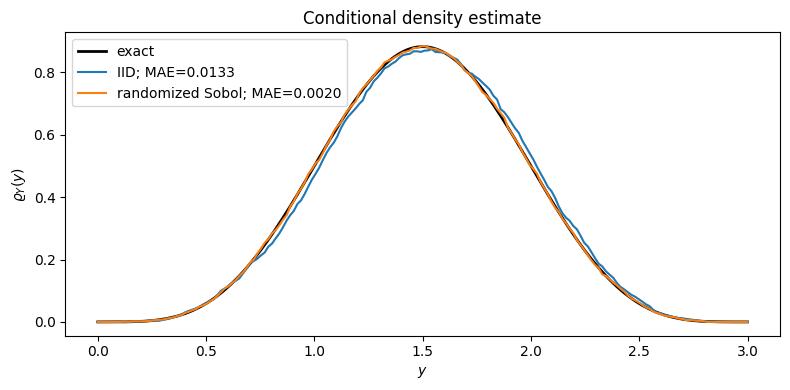

In [4]:
weights = np.array([1.0, 0.8, 0.6, 0.4, 0.2])
n = 2**10
y = np.linspace(0, weights.sum(), 180)
truth = exact_density(y, weights)
u_iid = qp.IIDStdUniform(len(weights)-1, seed=565)(n)
u_sobol = qp.DigitalNetB2(len(weights)-1, seed=565)(n)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(y,truth,'k',lw=2,label="exact")
for label,u in [("IID",u_iid),("randomized Sobol",u_sobol)]:
    estimate=conditional_density(y,u,weights)
    mae=np.mean(np.abs(estimate-truth))
    ax.plot(y,estimate,label=f"{label}; MAE={mae:.4f}")
ax.set(xlabel="$y$",ylabel=r"$\varrho_Y(y)$",title="Conditional density estimate")
ax.legend(); fig.tight_layout()
assert np.all(np.isfinite(truth))

## Histograms, KDE, and conditional density

- **Histogram:** divide the output axis into bins.
- **KDE:** smooth observed outputs with a bandwidth; SciPy's [Gaussian KDE](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html) defaults to Scott's rule.
- **CMC:** average an analytic conditional density. Here each fixed-point estimate is unbiased; finite-width histograms and KDE generally have smoothing bias. This does not guarantee smaller CMC density error for every choice or sample size.
- **Shared inputs:** histogram, KDE, and IID CMC use the same IID uniform rows. CMC ignores the first coordinate; the other methods simulate the full sum. Sobol' CMC uses the same row count in dimension $d-1$.
- **Error measure:** mean absolute error on the displayed grid, rather than an integrated error or confidence bound. Bin count and bandwidth are editable.

For equal-width bins $I_k$ of width $b>0$ and a nonnegative kernel $\kappa$ with $\int\kappa=1$, the pointwise estimates are
\begin{align*}
\widehat\varrho_{\mathrm{Hist}}(y)&=\frac1{nb}\sum_{i=0}^{n-1}\mathbf1\{Y_i\in I_k\},\quad y\in I_k,\\
\widehat\varrho_{\mathrm{KDE}}(y)&=\frac1{nb}\sum_{i=0}^{n-1}\kappa\!\left(\frac{y-Y_i}{b}\right),\\
\widehat\varrho_{\mathrm{CMC}}(y)&=\frac1n\sum_{i=0}^{n-1}\varrho_{Y\mid V}(y\mid V_i).
\end{align*}
Here $V$ is the retained conditioning variable (the tail uniforms in this example). For Gaussian KDE, $\kappa=\phi$, the standard normal density. The histogram and KDE can use different widths; CMC has no bandwidth parameter.


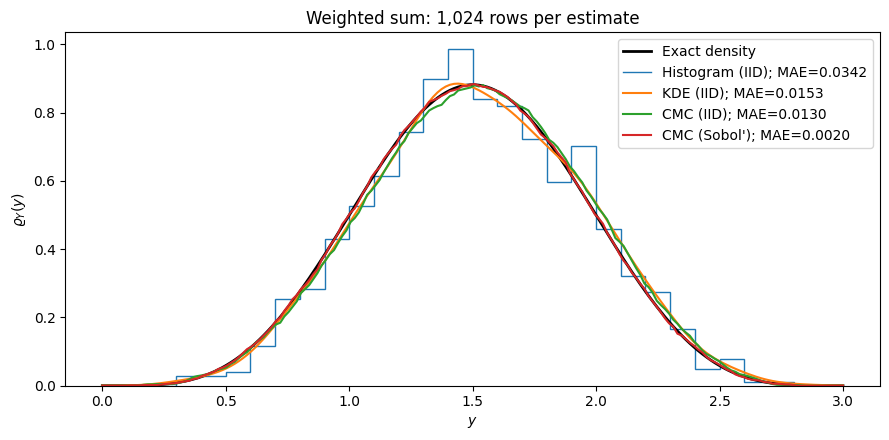

In [5]:
HIST_BINS = 30  # Try 15 or 60 to change the histogram resolution.
KDE_BANDWIDTH = "scott"  # Try "silverman", or a scalar bandwidth factor.
bin_edges = np.linspace(0, weights.sum(), HIST_BINS+1)

def histogram_density(grid, samples, edges):
    counts, _ = np.histogram(samples, bins=edges)
    heights = counts/(len(samples)*np.diff(edges))
    indices = np.searchsorted(edges, grid, side="right")-1
    indices = np.where(grid == edges[-1], len(heights)-1, indices)
    answer = np.zeros_like(grid, dtype=float)
    inside = (indices >= 0) & (indices < len(heights))
    answer[inside] = heights[indices[inside]]
    return answer

full_iid = qp.IIDStdUniform(len(weights), seed=565)(n)
sum_samples = full_iid @ weights
uniform_estimates = {
    "Histogram (IID)": histogram_density(y, sum_samples, bin_edges),
    "KDE (IID)": gaussian_kde(sum_samples, bw_method=KDE_BANDWIDTH)(y),
    "CMC (IID)": conditional_density(y, full_iid[:, 1:], weights),
    "CMC (Sobol')": conditional_density(y, u_sobol, weights),
}
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(y, truth, "k", lw=2, label="Exact density")
for label, estimate in uniform_estimates.items():
    error = np.mean(np.abs(estimate-truth))
    legend_label = f"{label}; MAE={error:.4f}"
    if label.startswith("Histogram"):
        heights, _ = np.histogram(sum_samples, bins=bin_edges, density=True)
        ax.stairs(heights, bin_edges, label=legend_label)
    else:
        ax.plot(y, estimate, label=legend_label)
ax.set(xlabel="$y$", ylabel=r"$\varrho_Y(y)$",
       title=f"Weighted sum: {n:,} rows per estimate")
ax.legend(); fig.tight_layout()


- **Repeat:** one realization can favor a method by chance. Use 16 independent seeds, keeping the grid, bin edges, and bandwidth rule fixed. Each KDE refits its bandwidth.
- **Time the calculation:** regenerate the same seeded rows for each method; include sampler construction, point generation, sum or conditional-density evaluation, and KDE fitting. Reference and plots are excluded.
- **Compare accuracy and work:** report grid MAE, its across-run SD, grid RMS error, and runtime. The product of mean squared grid error and mean seconds is a descriptive cost–error score at this sample size, not a universal efficiency law. Smoothing bias can persist as more independent density estimates are averaged.
- **Interpret the spread:** it measures variation in grid error across runs, rather than pointwise confidence intervals. Timings depend on the machine.


In [6]:
density_errors = {label: [] for label in uniform_estimates}
density_mse = {label: [] for label in uniform_estimates}
density_seconds = {label: [] for label in uniform_estimates}
for rep in range(16):
    for label in density_errors:
        started = time.perf_counter()
        if label == "CMC (Sobol')":
            rows = qp.DigitalNetB2(len(weights)-1, seed=2000+rep)(n)
            estimate = conditional_density(y, rows, weights)
        else:
            rows = qp.IIDStdUniform(len(weights), seed=2000+rep)(n)
            if label == "CMC (IID)":
                estimate = conditional_density(y, rows[:, 1:], weights)
            else:
                samples = rows @ weights
                estimate = (histogram_density(y, samples, bin_edges)
                            if label == "Histogram (IID)" else
                            gaussian_kde(samples, bw_method=KDE_BANDWIDTH)(y))
        density_seconds[label].append(time.perf_counter()-started)
        density_errors[label].append(np.mean(np.abs(estimate-truth)))
        density_mse[label].append(np.mean((estimate-truth)**2))
from IPython.display import display, Markdown
lines = ["| Method | Mean grid MAE | SD of grid MAE | Grid RMS error | Seconds / estimate | Grid MSE × seconds |",
         "|:--|--:|--:|--:|--:|--:|"]
for label, errors in density_errors.items():
    mse, elapsed = np.mean(density_mse[label]), np.mean(density_seconds[label])
    lines.append(f"| {label} | {np.mean(errors):.5f} | {np.std(errors, ddof=1):.5f} | "
                 f"{np.sqrt(mse):.5f} | {elapsed:.4f} | {mse*elapsed:.5g} |")
display(Markdown("\n".join(lines)))


| Method | Mean grid MAE | SD of grid MAE | Grid RMS error | Seconds / estimate | Grid MSE × seconds |
|:--|--:|--:|--:|--:|--:|
| Histogram (IID) | 0.03791 | 0.00425 | 0.05737 | 0.0001 | 4.1769e-07 |
| KDE (IID) | 0.01817 | 0.00473 | 0.02646 | 0.0008 | 5.568e-07 |
| CMC (IID) | 0.00739 | 0.00199 | 0.01034 | 0.0005 | 4.9624e-08 |
| CMC (Sobol') | 0.00253 | 0.00048 | 0.00356 | 0.0007 | 9.3908e-09 |

## Which coordinate should we integrate out?

The density is unchanged if we reorder the weights. Compare estimates across independent replications for two choices of $\gamma_1$.


In [7]:
orderings = {"largest first":weights, "smallest first":weights[::-1]}
repetitions=20
for name,w in orderings.items():
    errors=[]
    for rep in range(repetitions):
        u=qp.IIDStdUniform(len(w)-1, seed=1000+rep)(n)
        errors.append(np.mean(np.abs(conditional_density(y,u,w)-truth)))
    print(f"{name:15s}: mean absolute density error {np.mean(errors):.5f}")

largest first  : mean absolute density error 0.00772
smallest first : mean absolute density error 0.02389


Conditioning reduces the variance of a **CDF** estimator because a conditional expectation has no more variance than the original indicator. Differentiating the analytic conditional CDF yields the density estimate above, without choosing a histogram bandwidth. Its error still depends on the weights, the conditioned coordinate, and the sample design.


## Finance density: an arithmetic Asian average

- **Model and monitoring:** use the Asian-option companion's risk-neutral model: $S(t)=S_0\exp\{(r-\sigma^2/2)t+\sigma B(t)\}$, $t_j=jT/d$, and $A=d^{-1}\sum_{j=1}^d S(t_j)$. 
- **Task:** estimate the density of **the average asset price $A$**, rather than the expectation of an option payoff.

Write $B(t_j)=\sqrt{\Delta t}\,Z_1+R_j$, with $R_1=0$ and $R_j$ built from Brownian increments 2 through $j$. The first standard normal $Z_1$ is independent of the residual path. Conditional on that path,
\begin{align*}
C &= \frac{S_0}{d}\sum_{j=1}^d
     \exp\{(r-\sigma^2/2)t_j+\sigma R_j\},\\
A &= C\exp(sZ_1),\qquad s=\sigma\sqrt{\Delta t},\\
\varrho_{A\mid C}(a) &= \frac{1}{as}\phi\left(\frac{\log(a/C)}s\right),\qquad a>0,\\
F_{A\mid C}(a) &= \Phi\left(\frac{\log(a/C)}s\right).
\end{align*}
- **Average:** conditional densities or CDFs yield the corresponding unconditional quantities. No closed-form arithmetic-Asian density is assumed.
- **Generate:** QMCPy supplies IID/Sobol' points and chronological Cholesky Brownian maps. CMC integrates out the first increment and samples the remaining $d-1$ increments.
- **Memory:** process conditional densities and CDFs in blocks while retaining all `n_finance=2**18` rows.
- **Cost:** charge generation and path transformation to every method, including when the demonstration reuses arrays. Report runtime; without a reference density, do not assign a numerical accuracy ranking.

- **Assumptions:** equally spaced, right-endpoint monitoring and positive volatility. Integrating out one weekly increment may smooth less than a longer increment; performance depends on the conditioning choice.


| Method | Generation + transform + density seconds |
|:--|--:|
| Histogram (IID) | 0.289 |
| KDE (IID) | 0.467 |
| CMC (IID) | 1.342 |
| CMC (Sobol') | 1.330 |

Displayed range ends at 260; the Asian average has an unbounded right tail.
There is no exact reference curve here; agreement is not an error certificate.


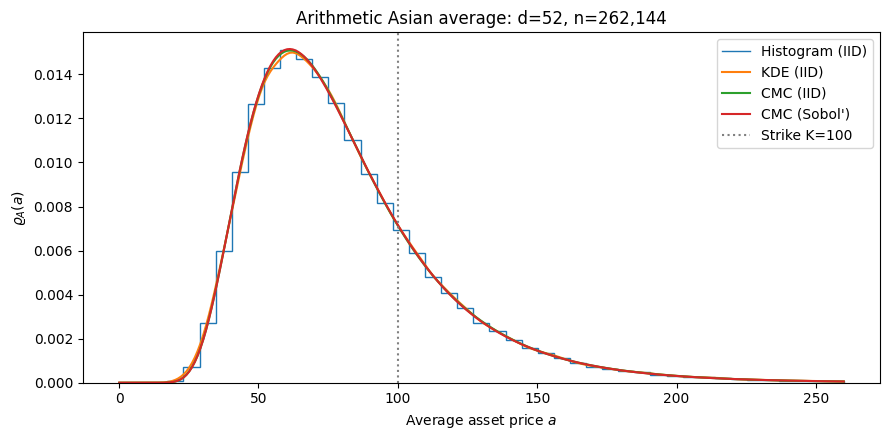

In [8]:
# Match the Asian Option Variance Reduction companion; these are editable.
S0, K, r, sigma, T, d = 80.0, 100.0, 0.03, 0.7, 1.0, 52
n_finance = 2**18
FINANCE_HIST_BINS = 45
FINANCE_KDE_BANDWIDTH = "scott"
assert d >= 2 and sigma > 0 and T > 0
dt = T/d
times = dt*np.arange(1, d+1)
s = sigma*np.sqrt(dt)

def average_from_path(w):
    return (S0*np.exp((r-sigma**2/2)*times + sigma*w)).mean(axis=-1)

def scale_from_residual_path(w):
    # BrownianMotion supplies R_2,...,R_d; R_1=0.
    residual = np.concatenate([np.zeros(w.shape[:-1]+(1,)), w], axis=-1)
    return average_from_path(residual)

average_integrand = qp.CustomFun(
    qp.BrownianMotion(qp.IIDStdUniform(d), t_final=T, decomp_type="Cholesky"),
    g=average_from_path)
scale_integrand = qp.CustomFun(
    qp.BrownianMotion(qp.IIDStdUniform(d-1), t_final=T-dt,
                     decomp_type="Cholesky"), g=scale_from_residual_path)

def asian_conditional(grid, scales, cdf=False, block_size=4096):
    grid = np.asarray(grid, dtype=float)
    scales = np.asarray(scales, dtype=float)
    if len(scales) == 0 or block_size < 1:
        raise ValueError("Use nonempty scales and a positive block size.")
    answer = np.zeros_like(grid)
    positive = grid > 0
    positive_grid = grid[positive]
    for start in range(0, len(scales), block_size):
        block = scales[start:start+block_size]
        z = np.log(positive_grid[None, :]/block[:, None])/s
        contributions = norm.cdf(z) if cdf else norm.pdf(z)/(positive_grid*s)
        answer[positive] += contributions.sum(axis=0)
    return answer/len(scales)

# Verify blocking against the direct formula on a small representative subset.
check_scales = np.linspace(20, 150, 37)
check_grid_small = np.array([-1.0, 0.0, 50.0, 100.0, 200.0])
for cdf in [False, True]:
    z = np.log(check_grid_small[2:][None, :]/check_scales[:, None])/s
    expected = np.zeros_like(check_grid_small)
    expected[2:] = (norm.cdf(z) if cdf else norm.pdf(z)/(check_grid_small[2:]*s)).mean(axis=0)
    np.testing.assert_allclose(asian_conditional(check_grid_small, check_scales,
                                                cdf=cdf, block_size=7), expected,
                               rtol=1e-13, atol=1e-15)

started = time.perf_counter()
finance_rows = qp.IIDStdUniform(d, seed=565)(n_finance)
averages = average_integrand.f(finance_rows).reshape(-1)
direct_path_seconds = time.perf_counter()-started
started = time.perf_counter()
# Charge the same IID generation separately to the conditioning method.
cmc_rows = qp.IIDStdUniform(d, seed=565)(n_finance)
scales_iid = scale_integrand.f(cmc_rows[:, 1:]).reshape(-1)
iid_scale_seconds = time.perf_counter()-started
started = time.perf_counter()
finance_sobol = qp.DigitalNetB2(d-1, seed=565)(n_finance)
scales_sobol = scale_integrand.f(finance_sobol).reshape(-1)
sobol_scale_seconds = time.perf_counter()-started
del cmc_rows
# Verify the first-increment factorization against the full QMCPy path map.
np.testing.assert_allclose(averages, scales_iid*np.exp(s*norm.ppf(finance_rows[:, 0])),
                           rtol=1e-12)
asset_grid = np.linspace(0.1, 260, 260)
finance_edges = np.linspace(0, asset_grid[-1], FINANCE_HIST_BINS+1)
finance_estimates, finance_seconds = {}, {}
for label, generation_cost, evaluate in [
    ("Histogram (IID)", direct_path_seconds,
     lambda: histogram_density(asset_grid, averages, finance_edges)),
    ("KDE (IID)", direct_path_seconds,
     lambda: gaussian_kde(averages, bw_method=FINANCE_KDE_BANDWIDTH)(asset_grid)),
    ("CMC (IID)", iid_scale_seconds, lambda: asian_conditional(asset_grid, scales_iid)),
    ("CMC (Sobol')", sobol_scale_seconds, lambda: asian_conditional(asset_grid, scales_sobol))]:
    started = time.perf_counter()
    finance_estimates[label] = evaluate()
    finance_seconds[label] = generation_cost+time.perf_counter()-started
lines = ["| Method | Generation + transform + density seconds |", "|:--|--:|"]
lines += [f"| {label} | {elapsed:.3f} |" for label, elapsed in finance_seconds.items()]
display(Markdown("\n".join(lines)))
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, estimate in finance_estimates.items():
    if label.startswith("Histogram"):
        counts, _ = np.histogram(averages, bins=finance_edges)
        ax.stairs(counts/(len(averages)*np.diff(finance_edges)), finance_edges, label=label)
    else:
        ax.plot(asset_grid, estimate, label=label)
ax.axvline(K, color="gray", ls=":", label=f"Strike K={K:g}")
ax.set(xlabel="Average asset price $a$", ylabel=r"$\varrho_A(a)$",
       title=f"Arithmetic Asian average: d={d}, n={n_finance:,}")
ax.legend(); fig.tight_layout()
print("Displayed range ends at 260; the Asian average has an unbounded right tail.")
print("There is no exact reference curve here; agreement is not an error certificate.")


## From the average density to the Asian-call payoff distribution

The discounted payoff $P=e^{-rT}(A-K)_+$ has a **point mass at zero**, with probability $F_A(K)$. Thus its full distribution cannot be represented by an ordinary density curve. For $p>0$, the continuous part has density
\begin{align*}
\varrho_P(p) = e^{rT}\varrho_A(K+e^{rT}p).
\end{align*}
Its integral is $1-F_A(K)$, rather than one. Plot that continuous part separately and report the zero-payoff probability. Applying ordinary KDE to all payoffs would blur the atom into a smooth bump.

The same conditional lognormal calculation also gives a conditional call expectation. Averaging it prices the option by CMC; this is a second consequence of the factorization, distinct from density estimation.


Zero-payoff probability (CMC): 0.77154
Positive-payoff probability:    0.22846
Asian-call price (CMC Sobol'):  7.16560
Asian-call price (direct IID): 7.22701


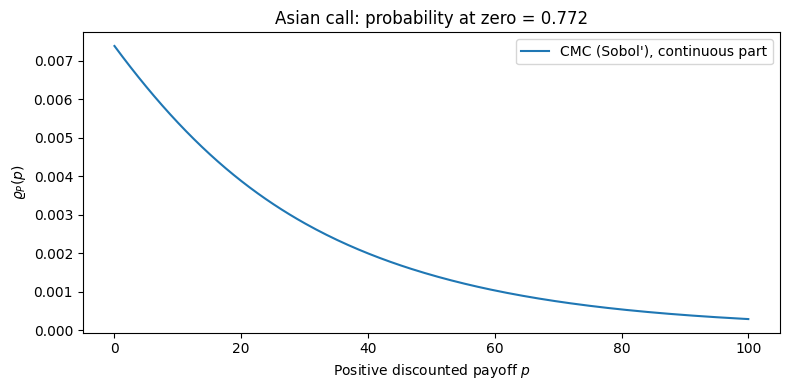

In [9]:
zero_probability = asian_conditional(np.array([K]), scales_sobol, cdf=True)[0]
payoff_grid = np.linspace(0.01, 100, 240)
payoff_density = np.exp(r*T)*asian_conditional(
    K+np.exp(r*T)*payoff_grid, scales_sobol)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(payoff_grid, payoff_density, label="CMC (Sobol'), continuous part")
ax.set(xlabel="Positive discounted payoff $p$", ylabel=r"$\varrho_P(p)$",
       title=f"Asian call: probability at zero = {zero_probability:.3f}")
ax.legend(); fig.tight_layout()

z_strike = np.log(scales_sobol/K)/s
conditional_calls = np.exp(-r*T)*(
    scales_sobol*np.exp(s*s/2)*norm.cdf(z_strike+s)-K*norm.cdf(z_strike))
print(f"Zero-payoff probability (CMC): {zero_probability:.5f}")
print(f"Positive-payoff probability:    {1-zero_probability:.5f}")
print(f"Asian-call price (CMC Sobol'):  {conditional_calls.mean():.5f}")
print(f"Asian-call price (direct IID): {np.exp(-r*T)*np.maximum(averages-K, 0).mean():.5f}")
# Structural checks: nonnegative density, monotone CDF, and correct endpoint limits.
check_grid = np.array([-1.0, 0.0, K, 1e8])
check_cdf = asian_conditional(check_grid, scales_sobol, cdf=True)
assert np.all(np.diff(check_cdf) >= 0) and check_cdf[0] == 0
assert np.isclose(check_cdf[-1], 1) and np.all(payoff_density >= 0)
assert 0 < zero_probability < 1 and np.all(conditional_calls >= -1e-12)

# Check the conditional density against the derivative of its CDF.
h = 1e-3
cdf_derivative = (asian_conditional(np.array([K+h]), scales_sobol, cdf=True)
                  - asian_conditional(np.array([K-h]), scales_sobol, cdf=True))/(2*h)
np.testing.assert_allclose(cdf_derivative,
                           asian_conditional(np.array([K]), scales_sobol), rtol=1e-7)
# Verify right-endpoint averaging against QMCPy's financial-option integrand.
asian_option = qp.FinancialOption(
    qp.IIDStdUniform(d), option="ASIAN", asian_mean="ARITHMETIC",
    asian_mean_quadrature_rule="RIGHT", start_price=S0, strike_price=K,
    interest_rate=r, volatility=sigma, t_final=T, decomp_type="Cholesky")
np.testing.assert_allclose(asian_option.f(finance_rows).reshape(-1),
                           np.exp(-r*T)*np.maximum(averages-K, 0), rtol=1e-12, atol=1e-11)


**Explore:**

- Change histogram bins or KDE bandwidth and compare error and runtime.
- Increase `n` or `n_finance`; KDE and CMC both evaluate many contributions across the density grid.
- Change `d` to monthly monitoring, remembering that this changes the contract.
- Keep the payoff's atom at zero separate from its continuous density.
- Compare methods at equal row counts, then assess whether added work buys useful accuracy.


In [10]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 4.9 sec.
